<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/01_resin_discovery_framework_gen_o2_temp/NRC_Postdoc_Project/01_Resin_Discovery_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created 'historical_lab_data_gen_o2_temp.csv' with 2000 samples.
Dataset preview (first 5 rows):


,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Resin_Generation,O2_Level,Temperature_C,Ec_mJ_cm2,Dp_um
0,Acrylate_Standard,0.655158,0.248766,2,0.455476,21.218218,15.491472,110.000287
1,Epoxy_Tough,1.645655,0.178229,1,0.118858,26.176080,10.458052,129.115928
2,Epoxy_Tough,0.822575,0.073456,3,0.569173,25.343047,10.997292,161.031447
3,Acrylate_Standard,0.880817,0.223703,3,0.156429,26.131397,13.721510,114.710019
4,Acrylate_Standard,2.080707,0.025344,1,0.060958,26.414754,8.976270,186.920141


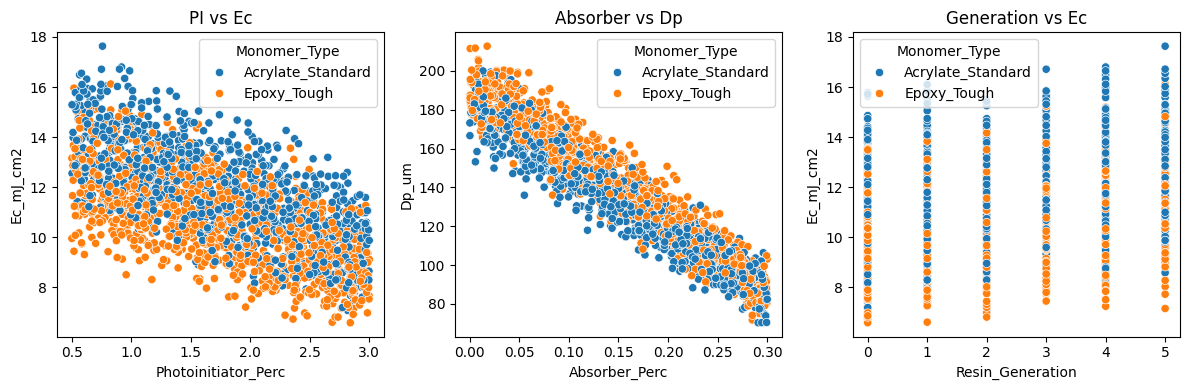

In [6]:
# CELL 1: Imports, configuration, and synthetic data generation

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

import torch
import torch.nn as nn

# --- CONFIGURATION ---
filename = "historical_lab_data_gen_o2_temp.csv"
random.seed(42)
np.random.seed(42)

n_samples = 2000  # synthetic dataset size

# --- 1. GENERATE INPUT FEATURES (FORMULATION + HISTORY + ENVIRONMENT) ---

rng = np.random.default_rng(42)

monomer_types = rng.choice(
    ["Acrylate_Standard", "Epoxy_Tough"],
    size=n_samples
)

photoinitiator_perc = rng.uniform(0.5, 3.0, size=n_samples)   # wt%
absorber_perc       = rng.uniform(0.0, 0.3, size=n_samples)   # wt%

# New features:
resin_generation = rng.integers(0, 6, size=n_samples)         # 0–5 reuse cycles
o2_level         = rng.uniform(0.0, 1.0, size=n_samples)      # 0 = low-O2, 1 = air
# Temperature: mostly around 25 °C, hard-bounded to [20, 30]
temperature_c    = rng.normal(25.0, 3.0, size=n_samples)
temperature_c    = np.clip(temperature_c, 20.0, 30.0)

df = pd.DataFrame({
    "Monomer_Type":         monomer_types,
    "Photoinitiator_Perc":  photoinitiator_perc,
    "Absorber_Perc":        absorber_perc,
    "Resin_Generation":     resin_generation,
    "O2_Level":             o2_level,
    "Temperature_C":        temperature_c,
})

# --- 2. PHYSICS-INSPIRED MODEL FOR Ec AND Dp ---

def calc_base_ec(row):
    """
    Base cure dose Ec (mJ/cm²) as a function of monomer, PI, and absorber.
    """
    base = 9.0  # baseline sensitivity

    # Epoxy slightly more reactive (lower Ec)
    if row["Monomer_Type"] == "Epoxy_Tough":
        base *= 0.9

    # More photoinitiator -> lower Ec (simple monotonic toy model)
    base *= 1.0 - 0.15 * (row["Photoinitiator_Perc"] - 1.5)

    # More absorber slightly increases required dose (less light makes it through)
    base *= 1.0 + 1.5 * row["Absorber_Perc"]

    return base


def calc_base_dp(row):
    """
    Base penetration depth Dp (µm) as a function of monomer, PI, and absorber.
    """
    base = 200.0  # baseline Dp

    if row["Monomer_Type"] == "Epoxy_Tough":
        base *= 1.05  # epoxy slightly higher Dp

    # More absorber -> shorter Dp
    base *= 1.0 - 1.8 * row["Absorber_Perc"]

    # PI has a small effect on Dp
    base *= 1.0 - 0.03 * (row["Photoinitiator_Perc"] - 1.5)

    return base


ec_list = []
dp_list = []

for _, row in df.iterrows():
    base_ec = calc_base_ec(row)
    base_dp = calc_base_dp(row)

    gen  = row["Resin_Generation"]
    o2   = row["O2_Level"]       # 0 = low-O2, 1 = air
    temp = row["Temperature_C"]  # °C

    # ---- Ec modifiers ----
    # Aging: Ec increases with reuse (PI depletion, inhibitor buildup)
    aging_factor_ec = 1.0 + 0.03 * gen        # +3% per generation

    # Oxygen: more O2 makes cure harder (inhibition)
    o2_factor_ec    = 1.0 + 0.08 * o2         # up to ~+8% in air

    # Temperature: hotter resin -> slightly lower Ec (faster kinetics)
    temp_factor_ec  = 1.0 - 0.03 * ((temp - 25.0) / 5.0)

    # ---- Dp modifiers ----
    # Aging: Dp decreases with reuse (more scattering/absorbers)
    aging_factor_dp = 1.0 - 0.02 * gen

    # Oxygen: more O2 slightly reduces effective Dp
    o2_factor_dp    = 1.0 - 0.05 * o2

    # Temperature: hotter -> slightly deeper Dp
    temp_factor_dp  = 1.0 + 0.02 * ((temp - 25.0) / 5.0)

    # Clip Dp factor so it doesn't go crazy
    dp_factor = max(0.4, aging_factor_dp * o2_factor_dp * temp_factor_dp)

    ec = base_ec * aging_factor_ec * o2_factor_ec * temp_factor_ec
    dp = base_dp * dp_factor

    # Add some experimental noise
    ec += rng.normal(0.0, 0.4)   # mJ/cm² noise
    dp += rng.normal(0.0, 6.0)   # µm noise

    ec_list.append(ec)
    dp_list.append(dp)

df["Ec_mJ_cm2"] = np.clip(ec_list, 1.0, None)
df["Dp_um"]     = np.clip(dp_list, 10.0, None)

# Save for reproducibility if desired
df.to_csv(filename, index=False)

print(f"Created '{filename}' with {n_samples} samples.")
print("Dataset preview (first 5 rows):")
display(df.head())

# Quick sanity plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x="Photoinitiator_Perc", y="Ec_mJ_cm2", hue="Monomer_Type")
plt.title("PI vs Ec")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x="Absorber_Perc", y="Dp_um", hue="Monomer_Type")
plt.title("Absorber vs Dp")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x="Resin_Generation", y="Ec_mJ_cm2", hue="Monomer_Type")
plt.title("Generation vs Ec")

plt.tight_layout()
plt.show()


In [7]:
# CELL 1b: Tiny numeric summary of key columns

summary_cols = [
    "Ec_mJ_cm2",
    "Dp_um",
    "Photoinitiator_Perc",
    "Absorber_Perc",
    "Resin_Generation",
    "O2_Level",
    "Temperature_C",
]

print("Basic summary stats (min / mean / max):\n")

for col in summary_cols:
    s = df[col]
    print(
        f"{col:20s} "
        f"min = {s.min():7.2f}  "
        f"mean = {s.mean():7.2f}  "
        f"max = {s.max():7.2f}"
    )


Basic summary stats (min / mean / max):

Ec_mJ_cm2            min =    6.59  mean =   11.21  max =   17.63
Dp_um                min =   70.34  mean =  138.64  max =  212.69
Photoinitiator_Perc  min =    0.50  mean =    1.75  max =    3.00
Absorber_Perc        min =    0.00  mean =    0.15  max =    0.30
Resin_Generation     min =    0.00  mean =    2.51  max =    5.00
O2_Level             min =    0.00  mean =    0.50  max =    1.00
Temperature_C        min =   20.00  mean =   24.97  max =   30.00


In [8]:
# CELL 2: Build feature matrix, train/test split, and scaling
# This cell prepares one shared train/test split and scaled features/targets so both the neural network and random forest use exactly the same data.


# Features: formulation + history + environment
feature_cols = [
    "Monomer_Type",
    "Photoinitiator_Perc",
    "Absorber_Perc",
    "Resin_Generation",
    "O2_Level",
    "Temperature_C",
]

X_raw_df = df[feature_cols]

# One-hot encode the monomer type; keep numeric features as-is
X_encoded = pd.get_dummies(
    X_raw_df,
    columns=["Monomer_Type"],
    drop_first=True,   # one dummy for Epoxy_Tough
)

feature_names = X_encoded.columns.tolist()
print("Feature columns used for ML:")
print(feature_names)

X_all = X_encoded.values.astype(np.float32)

# Targets: Ec and Dp
y_all = np.column_stack([
    df["Ec_mJ_cm2"].values.astype(np.float32),
    df["Dp_um"].values.astype(np.float32),
])

# --- IMPORTANT: split first, then fit scalers on training only (no leakage) ---
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_all,
    y_all,
    test_size=0.25,
    random_state=42,
)

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_np = X_scaler.fit_transform(X_train_raw)
X_test_np  = X_scaler.transform(X_test_raw)
y_train_np = y_scaler.fit_transform(y_train_raw)
y_test_np  = y_scaler.transform(y_test_raw)

print("Train shape (features):", X_train_np.shape, "Test shape:", X_test_np.shape)

# Torch tensors for the NN (scaled)
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test  = torch.tensor(y_test_np, dtype=torch.float32)


Feature columns used for ML:
['Photoinitiator_Perc', 'Absorber_Perc', 'Resin_Generation', 'O2_Level', 'Temperature_C', 'Monomer_Type_Epoxy_Tough']
Train shape (features): (1500, 6) Test shape: (500, 6)


In [9]:
# CELL 3: PyTorch MLP surrogate for Ec and Dp (uses the shared prep from CELL 2)

input_dim = X_train.shape[1]
output_dim = 2  # Ec and Dp

class ResinMLP(nn.Module):
    def __init__(self, in_dim, hidden1=64, hidden2=32, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, out_dim),
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResinMLP(input_dim, out_dim=output_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 120
batch_size = 128

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

for epoch in range(1, n_epochs + 1):
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_dataset)

    if epoch == 1 or epoch % 30 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(X_test.to(device))
            val_loss = criterion(val_pred, y_test.to(device)).item()
        print(f"Epoch {epoch:3d} | train MSE: {epoch_loss:.4f} | val MSE: {val_loss:.4f}")

# --- Evaluate on test set in original Ec/Dp units ---

model.eval()
with torch.no_grad():
    y_pred_test_scaled = model(X_test.to(device)).cpu().numpy()

# Inverse-transform predictions and targets back to original units
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)
y_test_orig = y_scaler.inverse_transform(y_test_np)

y_ec_pred_test = y_pred_test[:, 0]
y_dp_pred_test = y_pred_test[:, 1]
y_ec_test      = y_test_orig[:, 0]
y_dp_test      = y_test_orig[:, 1]

nn_ec_r2  = r2_score(y_ec_test, y_ec_pred_test)
nn_ec_mae = mean_absolute_error(y_ec_test, y_ec_pred_test)
nn_dp_r2  = r2_score(y_dp_test, y_dp_pred_test)
nn_dp_mae = mean_absolute_error(y_dp_test, y_dp_pred_test)

print("\nPyTorch MLP performance on held-out TEST set:")
print(f"   - Ec  R²: {nn_ec_r2:.3f}   MAE: {nn_ec_mae:.2f} mJ/cm²")
print(f"   - Dp  R²: {nn_dp_r2:.3f}   MAE: {nn_dp_mae:.1f} µm")


Epoch   1 | train MSE: 0.9712 | val MSE: 0.8688
Epoch  30 | train MSE: 0.0393 | val MSE: 0.0428
Epoch  60 | train MSE: 0.0370 | val MSE: 0.0432
Epoch  90 | train MSE: 0.0359 | val MSE: 0.0433
Epoch 120 | train MSE: 0.0349 | val MSE: 0.0433

PyTorch MLP performance on held-out TEST set:
   - Ec  R²: 0.954   MAE: 0.33 mJ/cm²
   - Dp  R²: 0.957   MAE: 5.0 µm


In [10]:
# CELL 4: Random Forest baseline using original (unscaled) features

from sklearn.ensemble import RandomForestRegressor

# Reuse the same split in raw feature space
X_train_rf, X_test_rf = X_train_raw, X_test_raw
y_train_rf, y_test_rf = y_train_raw, y_test_raw

# Split Ec and Dp targets
y_ec_train_rf = y_train_rf[:, 0]
y_dp_train_rf = y_train_rf[:, 1]
y_ec_test_rf  = y_test_rf[:, 0]
y_dp_test_rf  = y_test_rf[:, 1]

# Random Forest model for Ec
rf_ec = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_ec.fit(X_train_rf, y_ec_train_rf)
y_ec_pred_rf = rf_ec.predict(X_test_rf)

# Random Forest model for Dp
rf_dp = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_dp.fit(X_train_rf, y_dp_train_rf)
y_dp_pred_rf = rf_dp.predict(X_test_rf)

rf_ec_r2  = r2_score(y_ec_test_rf, y_ec_pred_rf)
rf_ec_mae = mean_absolute_error(y_ec_test_rf, y_ec_pred_rf)
rf_dp_r2  = r2_score(y_dp_test_rf, y_dp_pred_rf)
rf_dp_mae = mean_absolute_error(y_dp_test_rf, y_dp_pred_rf)

print("\nRandom Forest performance on held-out TEST set:")
print(f"   - Ec  R²: {rf_ec_r2:.3f}   MAE: {rf_ec_mae:.2f} mJ/cm²")
print(f"   - Dp  R²: {rf_dp_r2:.3f}   MAE: {rf_dp_mae:.1f} µm")



Random Forest performance on held-out TEST set:
   - Ec  R²: 0.932   MAE: 0.40 mJ/cm²
   - Dp  R²: 0.951   MAE: 5.4 µm


In [11]:
# CELL 5: Compare Random Forest vs PyTorch MLP and show example predictions

# 1) Metric comparison table (TEST set)
results = pd.DataFrame([
    {
        "Model": "RandomForest",
        "Target": "Ec",
        "R2_test": rf_ec_r2,
        "MAE_test": rf_ec_mae,
    },
    {
        "Model": "RandomForest",
        "Target": "Dp",
        "R2_test": rf_dp_r2,
        "MAE_test": rf_dp_mae,
    },
    {
        "Model": "PyTorch MLP",
        "Target": "Ec",
        "R2_test": nn_ec_r2,
        "MAE_test": nn_ec_mae,
    },
    {
        "Model": "PyTorch MLP",
        "Target": "Dp",
        "R2_test": nn_dp_r2,
        "MAE_test": nn_dp_mae,
    },
])

print("Model comparison on held-out TEST set (higher R² is better, lower MAE is better):")
display(results)

# 2) A few concrete test-set predictions: true vs RF vs NN

rng_preview = np.random.default_rng(123)
n_examples = 5
example_idx = rng_preview.choice(len(y_ec_test), size=n_examples, replace=False)

rows = []
for idx in example_idx:
    rows.append({
        "Ec_true_mJcm2":    y_ec_test[idx],
        "Ec_RF_mJcm2":      y_ec_pred_rf[idx],
        "Ec_NN_mJcm2":      y_ec_pred_test[idx],
        "Dp_true_um":       y_dp_test[idx],
        "Dp_RF_um":         y_dp_pred_rf[idx],
        "Dp_NN_um":         y_dp_pred_test[idx],
    })

examples_df = pd.DataFrame(rows)

print("\nExample TEST-set predictions (true vs Random Forest vs Neural Net):")
display(
    examples_df.round({
        "Ec_true_mJcm2": 2,
        "Ec_RF_mJcm2":   2,
        "Ec_NN_mJcm2":   2,
        "Dp_true_um":    1,
        "Dp_RF_um":      1,
        "Dp_NN_um":      1,
    })
)


Model comparison on held-out TEST set (higher R² is better, lower MAE is better):


,Model,Target,R2_test,MAE_test
0,RandomForest,Ec,0.932026,0.401404
1,RandomForest,Dp,0.951265,5.358165
2,PyTorch MLP,Ec,0.954337,0.332584
3,PyTorch MLP,Dp,0.957318,4.983413



Example TEST-set predictions (true vs Random Forest vs Neural Net):


,Ec_true_mJcm2,Ec_RF_mJcm2,Ec_NN_mJcm2,Dp_true_um,Dp_RF_um,Dp_NN_um
0,10.42,10.92,10.90,88.800003,98.2,94.699997
1,10.60,10.89,10.98,115.599998,117.7,119.099998
2,12.63,12.81,12.55,103.900002,106.2,103.099998
3,13.11,12.87,12.79,132.800003,129.8,134.500000
4,10.34,10.37,10.31,84.199997,90.7,98.599998


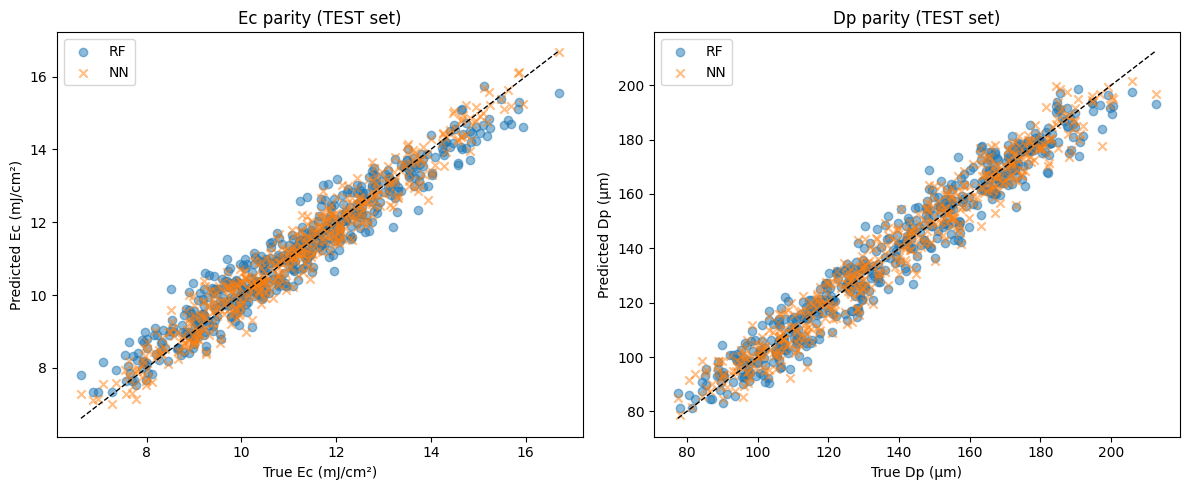


Pretend job predictions (Ec / Dp from RF and NN):


,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Resin_Generation,O2_Level,Temperature_C,Ec_RF_mJcm2,Dp_RF_um,Ec_NN_mJcm2,Dp_NN_um
0,Acrylate_Standard,1.5,0.05,1,0.3,24.0,10.14,179.1,10.11,177.500000
1,Epoxy_Tough,2.2,0.10,2,0.4,25.0,10.14,150.4,10.20,153.000000
2,Acrylate_Standard,1.0,0.20,4,0.8,26.0,14.76,112.7,14.76,115.599998


In [12]:
# CELL 6: Parity plots + pretend job predictions

# 1) Parity plots (true vs predicted on TEST set)

plt.figure(figsize=(12, 5))

# Ec parity
plt.subplot(1, 2, 1)
plt.scatter(y_ec_test, y_ec_pred_rf, alpha=0.5, label="RF")
plt.scatter(y_ec_test, y_ec_pred_test, alpha=0.5, marker="x", label="NN")

ec_min = min(y_ec_test.min(), y_ec_pred_rf.min(), y_ec_pred_test.min())
ec_max = max(y_ec_test.max(), y_ec_pred_rf.max(), y_ec_pred_test.max())
plt.plot([ec_min, ec_max], [ec_min, ec_max], "k--", linewidth=1)

plt.xlabel("True Ec (mJ/cm²)")
plt.ylabel("Predicted Ec (mJ/cm²)")
plt.title("Ec parity (TEST set)")
plt.legend()

# Dp parity
plt.subplot(1, 2, 2)
plt.scatter(y_dp_test, y_dp_pred_rf, alpha=0.5, label="RF")
plt.scatter(y_dp_test, y_dp_pred_test, alpha=0.5, marker="x", label="NN")

dp_min = min(y_dp_test.min(), y_dp_pred_rf.min(), y_dp_pred_test.min())
dp_max = max(y_dp_test.max(), y_dp_pred_rf.max(), y_dp_pred_test.max())
plt.plot([dp_min, dp_max], [dp_min, dp_max], "k--", linewidth=1)

plt.xlabel("True Dp (µm)")
plt.ylabel("Predicted Dp (µm)")
plt.title("Dp parity (TEST set)")
plt.legend()

plt.tight_layout()
plt.show()

# 2) Pretend job predictions (showing O2 + Temperature explicitly)

def predict_jobs(job_specs):
    """
    Take a list of dicts describing resin 'jobs' and return a table
    with Ec/Dp predictions from RF and NN.
    """
    rows = []
    for spec in job_specs:
        # Build a 1-row DataFrame in the same schema as feature_cols
        row_df = pd.DataFrame([{
            "Monomer_Type":        spec["Monomer_Type"],
            "Photoinitiator_Perc": spec["Photoinitiator_Perc"],
            "Absorber_Perc":       spec["Absorber_Perc"],
            "Resin_Generation":    spec["Resin_Generation"],
            "O2_Level":            spec["O2_Level"],
            "Temperature_C":       spec["Temperature_C"],
        }])

        # One-hot encode and align with training feature columns
        row_enc = pd.get_dummies(
            row_df,
            columns=["Monomer_Type"],
            drop_first=True,
        )

        for col in feature_names:
            if col not in row_enc.columns:
                row_enc[col] = 0.0

        row_enc = row_enc[feature_names].values.astype(np.float32)

        # Random Forest predictions (raw features)
        ec_rf = rf_ec.predict(row_enc)[0]
        dp_rf = rf_dp.predict(row_enc)[0]

        # Neural net predictions (scaled features -> inverse-transform)
        x_scaled = X_scaler.transform(row_enc)
        with torch.no_grad():
            x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)
            y_scaled_pred = model(x_tensor).cpu().numpy()
        ec_nn, dp_nn = y_scaler.inverse_transform(y_scaled_pred)[0]

        rows.append({
            "Monomer_Type":        spec["Monomer_Type"],
            "Photoinitiator_Perc": spec["Photoinitiator_Perc"],
            "Absorber_Perc":       spec["Absorber_Perc"],
            "Resin_Generation":    spec["Resin_Generation"],
            "O2_Level":            spec["O2_Level"],
            "Temperature_C":       spec["Temperature_C"],
            "Ec_RF_mJcm2":         ec_rf,
            "Dp_RF_um":            dp_rf,
            "Ec_NN_mJcm2":         ec_nn,
            "Dp_NN_um":            dp_nn,
        })

    return pd.DataFrame(rows)


# Example “today” jobs (tweak these as you like)
today_jobs = [
    {
        # Say this is "today's main job" you care about
        "Monomer_Type":        "Acrylate_Standard",
        "Photoinitiator_Perc": 1.5,
        "Absorber_Perc":       0.05,
        "Resin_Generation":    1,
        "O2_Level":            0.3,
        "Temperature_C":       24.0,
    },
    {
        "Monomer_Type":        "Epoxy_Tough",
        "Photoinitiator_Perc": 2.2,
        "Absorber_Perc":       0.10,
        "Resin_Generation":    2,
        "O2_Level":            0.4,
        "Temperature_C":       25.0,
    },
    {
        "Monomer_Type":        "Acrylate_Standard",
        "Photoinitiator_Perc": 1.0,
        "Absorber_Perc":       0.20,
        "Resin_Generation":    4,
        "O2_Level":            0.8,
        "Temperature_C":       26.0,
    },
]

today_predictions = predict_jobs(today_jobs)

print("\nPretend job predictions (Ec / Dp from RF and NN):")
display(
    today_predictions.round({
        "Photoinitiator_Perc": 2,
        "Absorber_Perc":       3,
        "O2_Level":            2,
        "Temperature_C":       1,
        "Ec_RF_mJcm2":         2,
        "Dp_RF_um":            1,
        "Ec_NN_mJcm2":         2,
        "Dp_NN_um":            1,
    })
)
